# Stock-Split-Modern — a quantitative teardown 🔬
### Market-adjusted abnormal CARs · a HAC horizon sweep · the pre/post-2020 era difference · a random-date placebo · a costed long/short timer · survivorship accounting · a seeded synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Real inverse drift%3F: Busted](https://img.shields.io/badge/Real_inverse_drift%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **the classic positive post-split drift survives in the post-2020 mega-cap era** — is re-tested with an **SPY-hedged, total-return abnormal-return** lens that de-trends the 2020-24 bull market, on *all* 44 forward splits since 2010, not the memorable few. The decisive statistic is a Newey-West HAC one-sample *t* on the date-ordered CARs.

> ⚠️ **Data note.** yfinance `.splits` (forward, ratio ≥ 1.5) + total-return (`auto_adjust`) closes for a 30-name large-cap basket **and SPY**, 2010→2025, cached. **Survivorship/selection is named on the Signal axis** — this is a *current-membership* basket of today's winners, a bias that points *for* the drift. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `f41f9d523e91`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stock_split_modern import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    SPLITS = data.load_splits()
    PANEL = st.build_event_panel(PRICES, SPLITS)
else:
    PRICES = SPLITS = PANEL = None
print("real cache present:", HAVE_REAL, "| forward-split events:",
      (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-08-24', 'end': '2025-11-17', 'asof': '2026-06-30', 'n_events': 44, 'n_pre': 19, 'n_post': 25, 'n_mega': 7, 'price_rows': 5406, 'all_n': 44, 'all_mean': -1.83, 'all_median': -2.65, 'all_thac': -0.82, 'all_tplain': -0.91, 'all_win': 45, 'pre_n': 19, 'pre_mean': 3.37, 'pre_thac': 1.48, 'pre_win': 63, 'post_n': 25, 'post_mean': -5.78, 'post_median': -5.45, 'post_thac': -2.21, 'post_tplain': -2.12, 'post_std': 13.62, 'post_win': 32, 'mega_mean': -4.95, 'mega_thac': -0.77, 'mega_win': 43, 'era_diff_welch': -2.42, 'post_raw3m': -2.95, 'post_mkt3m': 2.83, 'post_car3m': -5.78, 'post_raw12m': 21.63, 'post_mkt12m': 16.18, 'post_car12m': 5.44, 'sweep_post': {'1m (21d)': (-3.69, -2.27), '3m (63d)': (-5.78, -2.21), '6m (126d)': (-2.58, -0.76), '12m (252d)': (5.44, 0.97)}, 'sweep_all': {'1m (21d)': (-1.4, -0.94), '3m (63d)': (-1.83, -0.82), '6m (126d)': (0.85, 0.34), '12m (252d)': (5.07, 1.56)}, 'ex_post_mean': 0.46, 'ex_post_t': 0.66, 'placebo_obs': -5.78, 'placebo_mean': 4.81, 'placebo_sd': 3.95, 'placebo_p': 0.999, 'placebo_draws': 1500, 'timer5_gross': -5.78, 'timer5_net': -5.88, 'timer5_t': -2.16, 'timer5_sharpe': -0.55, 'timer5_worst': -34.5, 'evyr': 1.64, 'timer20_net': -6.18, 'timer20_t': -2.27, 'timer_mega_net': -5.05, 'timer_mega_t': -0.78, 'mega_events': [('TSLA', '2020-08-31', 5, 9.8, 16.4), ('AAPL', '2020-08-31', 4, -11.6, -12.8), ('NVDA', '2021-07-20', 4, 15.3, 2.9), ('AMZN', '2022-06-06', 20, 5.8, -8.2), ('GOOGL', '2022-07-18', 20, -5.5, -9.2), ('TSLA', '2022-08-25', 3, -34.4, -26.6), ('NVDA', '2024-06-10', 10, -14.0, 5.0)], 'syn_null_mean': 0.45, 'syn_null_sd': 0.79, 'syn_null_fire': 0, 'syn_planted_t': 4.05, 'syn_planted_mean': 8.57, 'fp': 'f41f9d523e91'}


real cache present: True | forward-split events: 44


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | all-splits abnormal 3m CAR **-1.83%**, HAC **t = -0.82**; pre-2020 +3.37% (t = 1.48, uncertifiable); post-2020 -5.78% (t = -2.21); era-difference Welch t = -2.42 |
| **Tradability** | `MIRAGE` | long timer net -5.88% (t = -2.16), ~1.6 events/yr, worst -34.5%; mega-cap net -5.05% (t = -0.78) |
| **Real inverse drift?** | `BUSTED` | post-2020 3m t = -2.21 but 6m t = -0.76, 12m t = 0.97; mega-cap t = -0.77 |

> 💡 In plain words: the upward drift is absent everywhere; the post-2020 *negative* blip clears |t| = 2 only at short horizons, reverses by a year, and disappears on the seven names the story is actually about.

## 1 · The claim, steelmanned

Let $r^{s}_{[0,h]}$ be stock $s$'s total return from its ex-split close to $h$ trading days later, and $r^{m}_{[0,h]}$ SPY's over the identical window. The **abnormal CAR** is $\text{CAR}^s_h = r^{s}_{[0,h]} - r^{m}_{[0,h]}$. The claims:

- **H₁ (drift).** $E[\text{CAR}_h] > 0$ for $h$ up to 12 months — stocks drift up *abnormally* after a split.
- **H₂ (modern).** The effect holds in the **post-2020** cohort, and specifically on the mega-cap splitters (TSLA/NVDA/AMZN/GOOGL/AAPL).
- **H₃ (capture).** A timer that buys the ex-date close banks it net of costs.

We find **H₁ rejected** (all-splits CAR₃ₘ -1.83%, HAC t = -0.82; not even the pre-2020 slice certifies, t = 1.48), **H₂ rejected and reversed** (post-2020 -5.78%, t = -2.21; mega-cap -4.95%, t = -0.77), **H₃ rejected** (the long timer loses; the short leg is un-borrowable).

## 2 · So what? — inference design

Split events **cluster in calendar time** (the 2022 wave especially), so a plain i.i.d. one-sample *t* overstates independence. The planned primary is a **Newey-West (Bartlett) HAC one-sample *t*** on the **date-ordered** abnormal CARs. We report it at four horizons (21/63/126/252d) for the *all*, *pre*, *post* and *mega* cohorts; the era split (2020-01-01) is tested as a **Welch difference**; the hit rate carries a **Wilson interval**; and a **random-non-split-date placebo** (same names, matched horizon) asks whether the split date beat a coin toss. Market-adjustment removes the bull-market confound; survivorship/selection bias **remains and points *for* H₁**, so a `NONE` here is conservative.

## 3 · How we'd know — the protocol

- **Events.** 44 forward splits (ratio ≥ 1.5) since 2010 with a usable 3m window; 19 pre-2020, 25 post-2020, 7 mega-cap.
- **Measure.** Abnormal CAR = stock − SPY total return, entered at the ex-date close (first earned return t+1 — the single documented lag), at 1/3/6/12m + a [−1, +1] around-ex window.
- **Headline.** HAC t per cohort × horizon; Welch t of the era difference; Wilson win rate; random-date placebo.
- **Execution (timer).** Buy the ex-date close, hold the horizon, 2 × one-way cost × NAV; long-only for forward splits (the short leg is graded as un-borrowable).
- **Control.** Synthetic raw-stock + market paths, planted-abnormal-drift knob; the null must not fire across 12 seeds.

## 4 · The teardown

### 4a · The cohort table — the upward drift is nowhere

Market-adjusted 3-month abnormal CAR, by cohort, with the HAC *t*.

                     n  mean_pct  median_pct  t_hac  t_plain   win
cohort                                                            
all 2010+           44     -1.83       -2.65  -0.82    -0.91  0.45
pre-2020            19      3.37        2.44   1.48     1.29  0.63
post-2020 (modern)  25     -5.78       -5.45  -2.21    -2.12  0.32
post-2020 mega-cap   7     -4.95       -5.45  -0.77    -0.77  0.43


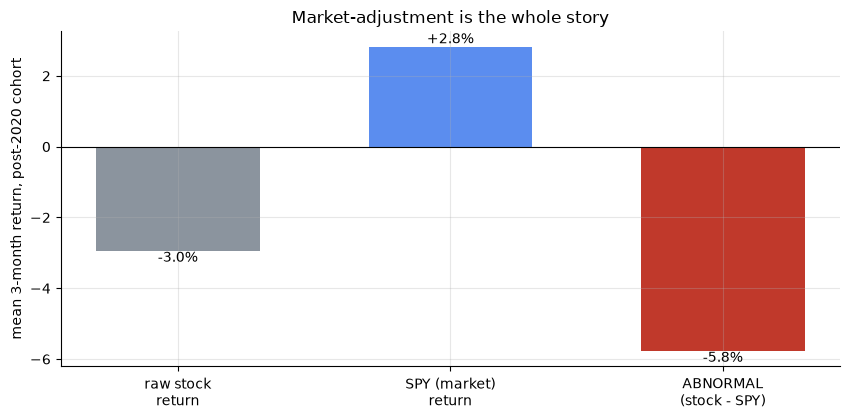

post-2020 3m: raw -2.95%  market +2.83%  abnormal -5.78%


In [2]:
if HAVE_REAL:
    ct = st.cohort_table(PANEL, 'car_3m')[['n','mean_pct','median_pct','t_hac','t_plain','win']]
    print(ct.round(2).to_string())
    rawpost = PANEL[PANEL['era']=='post']
    raw3, mkt3, car3 = rawpost['raw_3m'].mean()*100, rawpost['mkt_3m'].mean()*100, rawpost['car_3m'].mean()*100
else:
    raw3, mkt3, car3 = R['post_raw3m'], R['post_mkt3m'], R['post_car3m']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['raw stock\nreturn','SPY (market)\nreturn','ABNORMAL\n(stock - SPY)'],
       [raw3, mkt3, car3], color=[GREY, '#5b8def', RED], width=.6)
for i,v in enumerate([raw3, mkt3, car3]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean 3-month return, post-2020 cohort')
ax.set_title('Market-adjustment is the whole story')
plt.tight_layout(); plt.show()
print(f'post-2020 3m: raw {raw3:+.2f}%  market {mkt3:+.2f}%  abnormal {car3:+.2f}%')

> 💡 In plain words: pooled over all 44 splits the abnormal CAR₃ₘ is **-1.83% (HAC t = -0.82)** — no drift. The pre-2020 slice has the right sign (**+3.37%**) but only **t = 1.48** on 19 events — the anomaly can't even certify on its *home* era here. Post-2020 the mean goes **-5.78%**, and the Welch t of the pre→post difference is **-2.42**: a genuine regime change *away* from the drift.

### 4b · The HAC horizon sweep — the modern dip is fragile

The post-2020 cohort's abnormal CAR and HAC *t* across all four horizons, next to the all-cohort sweep.

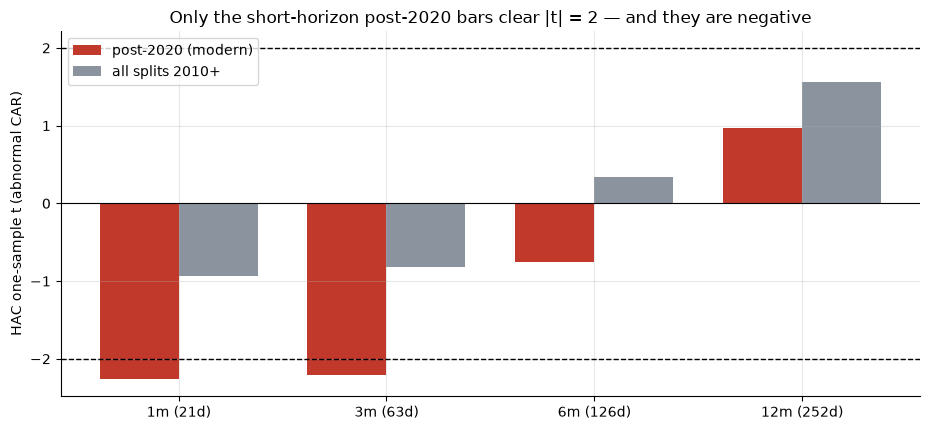

post-2020 HAC t: {'1m (21d)': -2.26, '3m (63d)': -2.21, '6m (126d)': -0.76, '12m (252d)': 0.96}
all-splits HAC t: {'1m (21d)': -0.94, '3m (63d)': -0.82, '6m (126d)': 0.34, '12m (252d)': 1.56}


In [3]:
labels = list(R['sweep_post'].keys())
if HAVE_REAL:
    hp = st.horizon_sweep(PANEL, 'post'); ha = st.horizon_sweep(PANEL, 'all')
    tp = list(hp['t_hac']); ta = list(ha['t_hac'])
else:
    tp = [R['sweep_post'][l][1] for l in labels]; ta = [R['sweep_all'][l][1] for l in labels]
x = np.arange(len(labels)); w = .38
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.bar(x-w/2, tp, width=w, color=RED, label='post-2020 (modern)')
ax.bar(x+w/2, ta, width=w, color=GREY, label='all splits 2010+')
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(-2, ls='--', c='k', lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('HAC one-sample t (abnormal CAR)')
ax.set_title('Only the short-horizon post-2020 bars clear |t| = 2 — and they are negative')
ax.legend(); plt.tight_layout(); plt.show()
print('post-2020 HAC t:', {l: round(v,2) for l,v in zip(labels, tp)})
print('all-splits HAC t:', {l: round(v,2) for l,v in zip(labels, ta)})

> 💡 In plain words: the post-2020 cohort clears |t| = 2 only at 1m (t = -2.27) and 3m (t = -2.21) — and *negative*. By 6m it's t = -0.76 and by 12m it has flipped to **+5.44% (t = 0.97)**. The *all-splits* sweep clears the bar at **no** horizon. Around the ex-date itself the modern cohort is a flat +0.46% (t = 0.66).

### 4c · The placebo — was the split date even a good entry?

Same names, entered on **random non-split dates**, market-adjusted; 1,500 baskets. In-notebook we draw from the frozen placebo moments; the canonical p is in `results.md`.

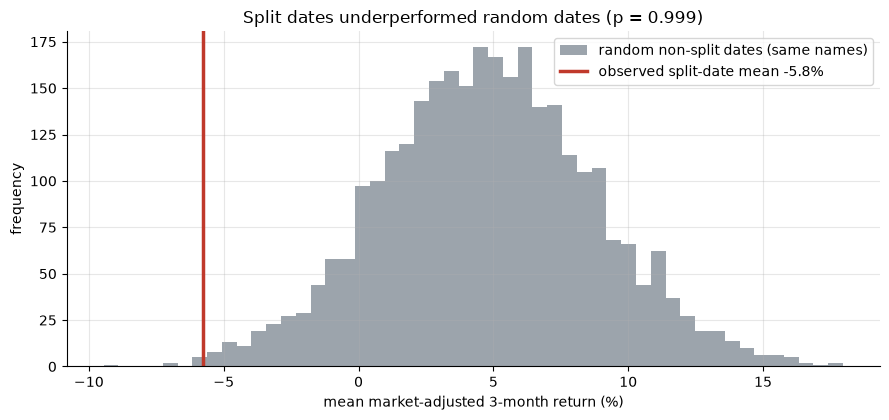

observed -5.78% vs placebo mean +4.81% (sd 3.95); random beat split ~99.9% of the time


In [4]:
obs = R['placebo_obs']; pm, ps = R['placebo_mean'], R['placebo_sd']
rng = np.random.default_rng(802)
draws = rng.normal(pm, ps, 3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='random non-split dates (same names)')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed split-date mean {obs:+.1f}%')
ax.set_xlabel('mean market-adjusted 3-month return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Split dates underperformed random dates (p = {R["placebo_p"]:.3f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}% vs placebo mean {pm:+.2f}% (sd {ps:.2f}); random beat split ~{R["placebo_p"]*100:.1f}% of the time')

> 💡 In plain words: the split-date basket returned **-5.78%** vs **+4.81%** for random dates in the same names — the split date was a *worse* entry (**p = 0.999**). A bullish signal would show the reverse. Consistent with a mild 'sell the news', inconsistent with post-split drift.

### 4d · The timer — an honest cost sweep

Buy the ex-date close, hold 3 months, market-hedged (long the stock, short SPY), 2 × one-way cost per event.

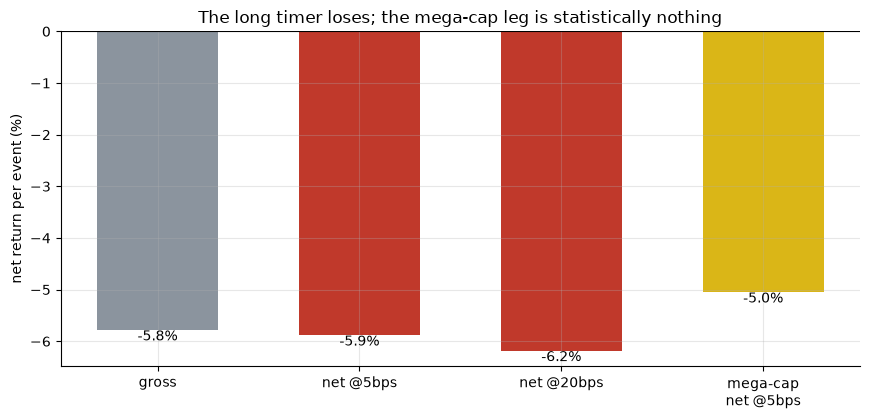

post long: gross -5.78% net@5 -5.88% (t=-2.16) net@20 -6.18% | mega net -5.05% (t=-0.78)


In [5]:
if HAVE_REAL:
    t5 = st.timer_stats(PANEL, 'car_3m', cost_bps=5.0, cohort='post')
    t20 = st.timer_stats(PANEL, 'car_3m', cost_bps=20.0, cohort='post')
    tm = st.timer_stats(PANEL, 'car_3m', cost_bps=5.0, cohort='mega')
    g, n5, n20 = t5['gross_pct'], t5['net_pct'], t20['net_pct']
    tt5, ttm = t5['t_net'], tm['t_net']; nm = tm['net_pct']
else:
    g, n5, n20 = R['timer5_gross'], R['timer5_net'], R['timer20_net']
    tt5, ttm, nm = R['timer5_t'], R['timer_mega_t'], R['timer_mega_net']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(['gross','net @5bps','net @20bps','mega-cap\nnet @5bps'], [g, n5, n20, nm],
       color=[GREY, RED, RED, AMBER], width=.6)
for i,v in enumerate([g, n5, n20, nm]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net return per event (%)')
ax.set_title('The long timer loses; the mega-cap leg is statistically nothing')
plt.tight_layout(); plt.show()
print(f'post long: gross {g:+.2f}% net@5 {n5:+.2f}% (t={tt5:+.2f}) net@20 {n20:+.2f}% | mega net {nm:+.2f}% (t={ttm:+.2f})')

> 💡 In plain words: the long timer nets **-5.88%** per event (t = -2.16) — it *loses*, because the modern abnormal return is negative. Flipping to a **short** would mean borrowing high-beta mega-caps and eating a **-34.5%** single-event tail (Tesla, Aug-2022) on ~1.6 events a year — un-scalable, and often un-borrowable. On the seven actual mega-caps the timer nets **-5.05% (t = -0.78)** — nothing. **Tradability = MIRAGE.**

### 4e · Faithful-engine & power control — we know the truth here

Synthetic raw stock + market price paths with synthetic split dates and a TUNABLE planted **abnormal** post-split drift, run through the *same* market-adjusted panel. The null (planted = 0) is checked over **12 seeds**.

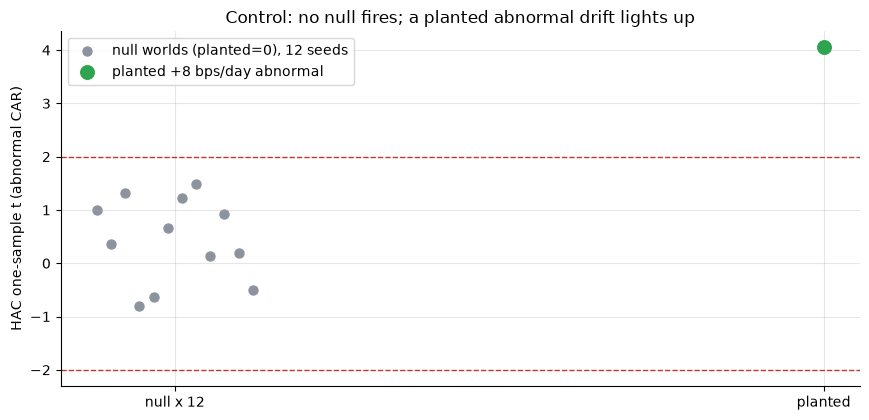

null: mean t = +0.45 (sd 0.79), |t|>=2 in 0/12 seeds  |  planted t = +4.05


In [6]:
null_ts = []
for s_ in range(12):
    pr, mk, sp = data.synthetic_world(planted_bps=0.0, seed=802 + s_)
    null_ts.append(st.synthetic_detect(pr, sp)['t_hac'])
null_ts = np.asarray(null_ts)
pr, mk, sp = data.synthetic_world(planted_bps=8.0, seed=802)
planted_t = st.synthetic_detect(pr, sp)['t_hac']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,12), null_ts, color=GREY, s=42, label='null worlds (planted=0), 12 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=95, zorder=5, label='planted +8 bps/day abnormal')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 12', 'planted'])
ax.set_ylabel('HAC one-sample t (abnormal CAR)')
ax.set_title('Control: no null fires; a planted abnormal drift lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/12 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 12 null worlds the detector averages t = +0.45 (sd 0.79) and fires |t| ≥ 2 in 0/12 seeds; a planted +8 bps/day abnormal drift reads t = 4.05 (mean CAR +8.57%). The machinery is unbiased and powered — so the real-tape *absence* of positive drift is genuine, not a dead pipeline. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — all-splits abnormal CAR₃ₘ **-1.83%** (HAC t = -0.82); pre-2020 +3.37% (t = 1.48, right sign but uncertifiable); post-2020 -5.78% (t = -2.21); era-difference Welch t = -2.42. No cohort clears **t ≥ 2 positive** on the real tape; if anything the anomaly reversed.
- **Tradability `MIRAGE`** — long timer net -5.88% (t = -2.16), ~1.6 events/yr, worst -34.5%; mega-cap net -5.05% (t = -0.78); the short leg is un-borrowable/un-scalable.
- **Real inverse drift? `BUSTED`** — the post-2020 −5.78% clears |t| = 2 only at 1-3m, reverses to +5.44% by 12m, and vanishes on the seven mega-caps (t = -0.77). A horizon-fragile, selection-biased 'sell-the-news' blip, not a tradable inverse drift.

## 6 · Going further

- **Effective vs announcement.** yfinance gives the *ex* date; the 1996 drift is measured from the *announcement* (~3-6 weeks earlier). The ex-date result being dead is consistent with the announcement signal being fully priced by the ex-date — the clean follow-up is to pull SEC 8-K announcement dates and re-run.
- **Why the modern sign flips.** Post-2020 mega-cap splits arrived *after* enormous run-ups, into crowded, options-heavy names — a setup for near-term mean reversion ('sell the news'), not continuation. Testable: does the dip scale with the pre-split run-up?
- **Dedup map:** [142-split-drift](../../142-split-drift/) (same anomaly, 2000-2025 basket, `NONE`), [250-reverse-split](../../250-reverse-split/) (the opposite corporate action, distress-confounded `WEAK`/`Mirage`).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*